# Évolution temporelle des profils verticaux de flux de quantité de mouvement
Ce notebook calcule et visualise l'évolution dans le temps des profils verticaux du flux de Reynolds $\overline{u'w'}$ et $\overline{v'w'}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## 1. Chargement des données

In [2]:
print("Chargement des fichiers NetCDF...")

ds_ua = xr.open_dataset("3D/MESONH_RCE_small300_3D_ua.nc")
ds_va = xr.open_dataset("3D/MESONH_RCE_small300_3D_va.nc")
ds_wa = xr.open_dataset("3D/MESONH_RCE_small300_3D_wa.nc")

u = ds_ua["ua"]
v = ds_va["va"]
w = ds_wa["wa"]

print(f"Forme des données : {u.shape}  (Temps, Altitude, Y, X)")
print(f"Nombre de pas de temps : {u.sizes['time']}")
print(f"Nombre de niveaux verticaux : {u.sizes['altitude']}")

Chargement des fichiers NetCDF...
Forme des données : (100, 74, 100, 100)  (Temps, Altitude, Y, X)
Nombre de pas de temps : 100
Nombre de niveaux verticaux : 74


In [3]:
print(u["time"])

<xarray.DataArray 'time' (time: 100)> Size: 800B
array([6501600000000000, 6523200000000000, 6544800000000000, 6566400000000000,
       6588000000000000, 6609600000000000, 6631200000000000, 6652800000000000,
       6674400000000000, 6696000000000000, 6717600000000000, 6739200000000000,
       6760800000000000, 6782400000000000, 6804000000000000, 6825600000000000,
       6847200000000000, 6868800000000000, 6890400000000000, 6912000000000000,
       6933600000000000, 6955200000000000, 6976800000000000, 6998400000000000,
       7020000000000000, 7041600000000000, 7063200000000000, 7084800000000000,
       7106400000000000, 7128000000000000, 7149600000000000, 7171200000000000,
       7192800000000000, 7214400000000000, 7236000000000000, 7257600000000000,
       7279200000000000, 7300800000000000, 7322400000000000, 7344000000000000,
       7365600000000000, 7387200000000000, 7408800000000000, 7430400000000000,
       7452000000000000, 7473600000000000, 7495200000000000, 7516800000000000,
   

On a un pas de temps toutes les 6 heures. La simulation couvre du jour 75 au jour 100 !

## 2. Décomposition de Reynolds et calcul des profils — pour chaque pas de temps

In [4]:
print("Décomposition de Reynolds (anomalies par rapport à la moyenne horizontale)...")

# Moyenne horizontale (dépend de time et altitude uniquement)
u_mean = u.mean(dim=["x", "y"])
v_mean = v.mean(dim=["x", "y"])
w_mean = w.mean(dim=["x", "y"])

# Fluctuations turbulentes
u_prime = u - u_mean
v_prime = v - v_mean
w_prime = w - w_mean

# Flux de Reynolds instantanés (moyennés horizontalement)
# Résultat : tableau 2D (time × altitude) — profil vertical à chaque instant
flux_u = (u_prime * w_prime).mean(dim=["x", "y"])  # shape: (time, altitude)
flux_v = (v_prime * w_prime).mean(dim=["x", "y"])  # shape: (time, altitude)

print(f"Forme des profils flux_u(t, z) : {flux_u.shape}")

# Axe temps en jours
temps_jours = u["time"].astype("float64") / (1e9 * 3600 * 24)
axe_z = u["altitude"].values

Décomposition de Reynolds (anomalies par rapport à la moyenne horizontale)...
Forme des profils flux_u(t, z) : (100, 74)


## 3. Diagramme de Hovmöller — $\overline{u'w'}$ et $\overline{v'w'}$

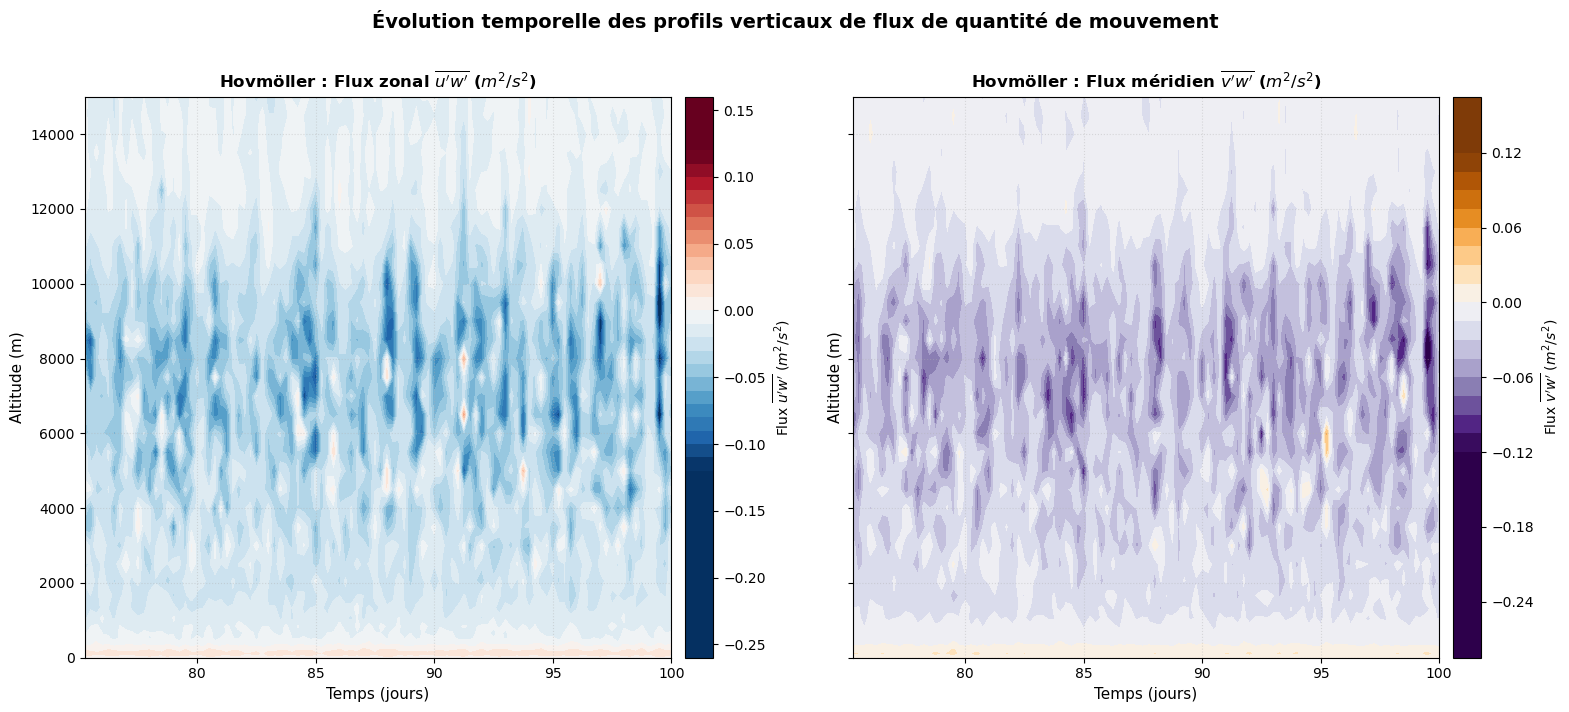

Figure sauvegardée : hovmoller_flux_reynolds.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, flux, label, cmap, title in zip(
    axes,
    [flux_u, flux_v],
    ["$\\overline{u'w'}$", "$\\overline{v'w'}$"],
    ["RdBu_r", "PuOr_r"],
    [
        "Hovmöller : Flux zonal $\\overline{u'w'}$ ($m^2/s^2$)",
        "Hovmöller : Flux méridien $\\overline{v'w'}$ ($m^2/s^2$)",
    ],
):
    flux_vals = flux.values.T  # shape: (altitude, time)

    # Normalisation symétrique autour de 0
    vmax = np.nanpercentile(np.abs(flux_vals), 99)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    cf = ax.contourf(
        temps_jours.values,
        axe_z,
        flux_vals,
        levels=40,
        cmap=cmap,
        norm=norm,
    )
    cb = fig.colorbar(cf, ax=ax, pad=0.02)
    cb.set_label(f"Flux {label} ($m^2/s^2$)", fontsize=10)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Temps (jours)", fontsize=11)
    ax.set_ylabel("Altitude (m)", fontsize=11)
    ax.set_ylim(0, 15000)
    ax.grid(True, linestyle=":", alpha=0.4)

plt.suptitle(
    "Évolution temporelle des profils verticaux de flux de quantité de mouvement",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()

plt.show()
print("Figure sauvegardée : hovmoller_flux_reynolds.png")

## 4. Profils à des instants clés (début, milieu, fin + moyennes de périodes)

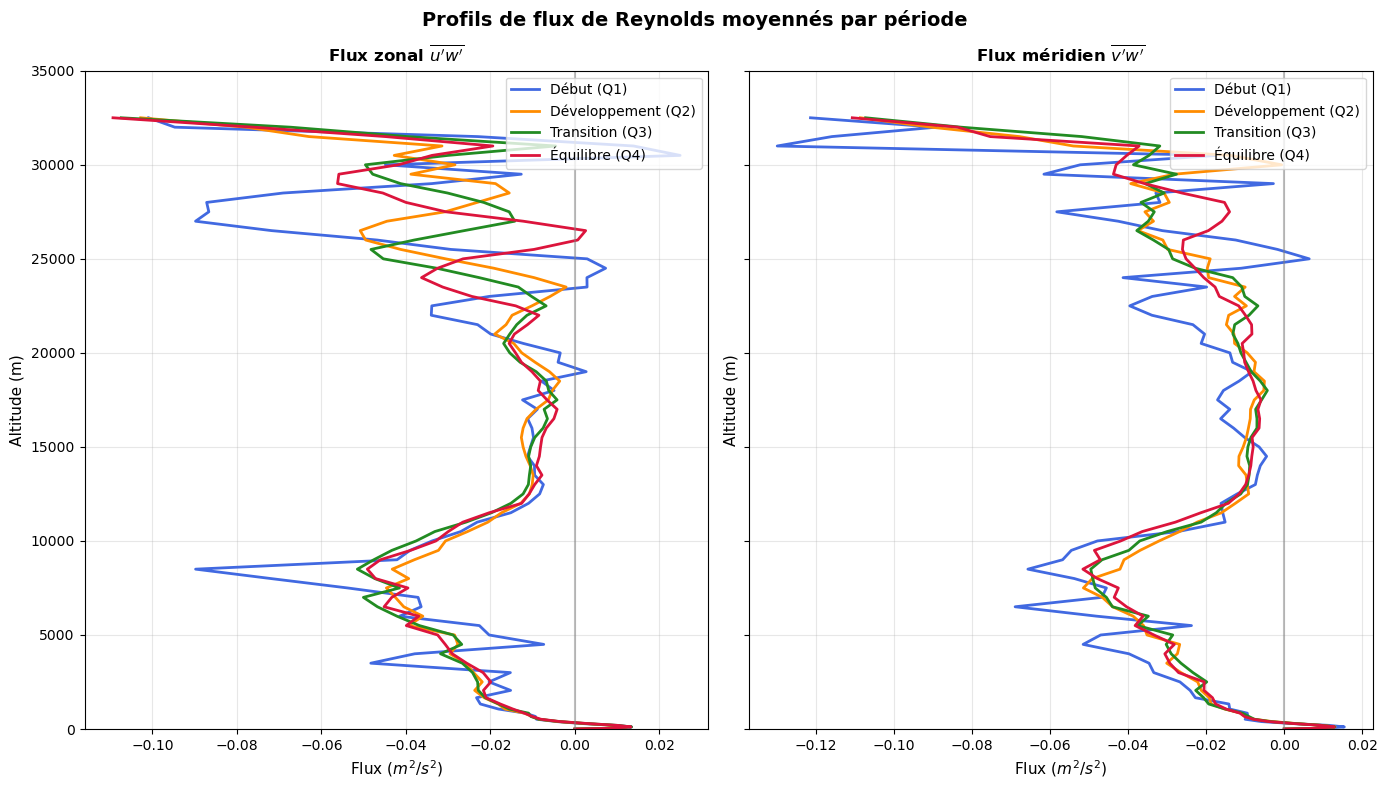

Figure sauvegardée : profils_par_periode.png


In [6]:
n_temps = flux_u.sizes["time"]

# Découpage de la simulation en 4 quarts
periodes = {
    "Début (Q1)": slice(0, n_temps // 50),
    "Développement (Q2)": slice(n_temps // 4, n_temps // 2),
    "Transition (Q3)": slice(n_temps // 2, 3 * n_temps // 4),
    "Équilibre (Q4)": slice(3 * n_temps // 4, None),
}

couleurs = ["royalblue", "darkorange", "forestgreen", "crimson"]

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

for ax, flux, label, titre in zip(
    axes,
    [flux_u, flux_v],
    ["$\\overline{u'w'}$", "$\\overline{v'w'}$"],
    [
        "Flux zonal $\\overline{u'w'}$",
        "Flux méridien $\\overline{v'w'}$",
    ],
):
    for (nom_periode, indices), couleur in zip(periodes.items(), couleurs):
        profil_moyen = flux.isel(time=indices).mean(dim="time").values
        ax.plot(
            profil_moyen,
            axe_z,
            label=nom_periode,
            color=couleur,
            linewidth=2,
        )

    ax.axvline(0, color="grey", linestyle="-", alpha=0.5)
    ax.set_title(titre, fontsize=12, fontweight="bold")
    ax.set_xlabel("Flux ($m^2/s^2$)", fontsize=11)
    ax.set_ylabel("Altitude (m)", fontsize=11)
    ax.set_ylim(0, 35000)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="upper right")

plt.suptitle(
    "Profils de flux de Reynolds moyennés par période",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()

plt.show()
print("Figure sauvegardée : profils_par_periode.png")

## 5. Animation : profil vertical évoluant dans le temps

In [7]:
# Sous-échantillonnage pour alléger l'animation (1 frame tous les N pas de temps)
pas_anim = max(1, n_temps // 50)  # ~50 frames max
indices_anim = np.arange(0, n_temps, pas_anim)

flux_u_vals = flux_u.values  # (time, altitude)
flux_v_vals = flux_v.values

# Limites fixes sur X pour les deux panneaux
vmax_u = np.nanpercentile(np.abs(flux_u_vals), 99)
vmax_v = np.nanpercentile(np.abs(flux_v_vals), 99)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

(line_u,) = ax1.plot([], [], color="black", linewidth=2, label="$\\overline{u'w'}$")
(line_v,) = ax2.plot([], [], color="purple", linewidth=2, label="$\\overline{v'w'}$")
title_text = fig.suptitle("", fontsize=13, fontweight="bold")

for ax, vmax, title_ax, label in zip(
    [ax1, ax2],
    [vmax_u, vmax_v],
    [
        "Flux zonal $\\overline{u'w'}$ ($m^2/s^2$)",
        "Flux méridien $\\overline{v'w'}$ ($m^2/s^2$)",
    ],
    ["Flux ($m^2/s^2$)", "Flux ($m^2/s^2$)"],
):
    ax.set_xlim(-vmax * 1.1, vmax * 1.1)
    ax.set_ylim(0, 15000)
    ax.axvline(0, color="grey", alpha=0.5)
    ax.set_title(title_ax, fontsize=11, fontweight="bold")
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Altitude (m)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

def init():
    line_u.set_data([], [])
    line_v.set_data([], [])
    return line_u, line_v

def update(frame_idx):
    t = indices_anim[frame_idx]
    line_u.set_data(flux_u_vals[t, :], axe_z)
    line_v.set_data(flux_v_vals[t, :], axe_z)
    jour = float(temps_jours.values[t])
    title_text.set_text(f"Profils de flux de Reynolds — Jour {jour:.1f}")
    return line_u, line_v, title_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(indices_anim),
    init_func=init,
    interval=100,
    blit=False,
)

# Sauvegarde en GIF
anim.save("animation_flux_reynolds.gif", writer="pillow", fps=10, dpi=100)
print("Animation sauvegardée : animation_flux_reynolds.gif")

# Affichage inline dans le notebook
plt.close()
HTML(anim.to_jshtml())

Animation sauvegardée : animation_flux_reynolds.gif
